(rasterising-lines-section)=
# Drawing lines

One of the fundamental tasks in computer graphics is the rendering of a straight line on a display. Consider the diagram in {numref}`line-raster-figure` showing the rasterisation of the straight line joining the two points with pixel co-ordinates $(2, 2)$ and $(12, 6)$. The pixels that are closest to the line are shaded to create a rasterised approximation of the idealise image. This is a simple task for a human since we are able to view the idealised image and determine which pixels need to be shaded. Algorithms are required to determine which pixels to illuminate in order to rasterise straight lines

```{figure} /images/line_raster.png
:name: line-raster-figure
:width: 400px

Rasterising a straight line
```

## Bresenham's algorithm

```{figure} https://www.ithistory.org/sites/default/files/honor-roll/Jack%20E.%20Bresenham.jpg
---
width: 200px
alt: Jack Elton Bresenham
figclass: margin
---
[Jack Elton Bresenham](https://en.wikipedia.org/wiki/Jack_Elton_Bresenham)
```

**Bresenham's algorithm** developed by American computer scientist Jack {cite:t}`bresenham1965algorithm` is a line drawing algorithm that uses integer only arithmetic and offers a vast improvement over other methods in terms of computational efficiency. Consider the [Cartesian equation of a straight line](https://en.wikipedia.org/wiki/Linear_equation) joining two points with co-ordinates $(x_0, y_0)$ and $(x_1, y_1)$

```{math}
:label: cartesian-equation-of-a-line
y = \frac{y_1 - y_0}{x_1 - x_0} x + c,
```

where $(x, y)$ are the co-ordinates of a point on the line and $c$ is where the line intercepts with the $y$-axis. Letting $\Delta x = x_1 - x_0$ and $\Delta y = y_1 - y_0$ this can be written as

$$y = \frac{\Delta y}{\Delta x} x + c, $$

which can be rearranged to give

$$ 0 = x \Delta y - y \Delta x + c \Delta x.$$

Defining the function $f(x, y)$ as

```{math}
:label: fxy

f(x, y) = x \Delta y - y \Delta x + c \Delta x,
```

then if $f(x, y) = 0$ then the point with co-ordinates $(x, y)$ is on the line else it gives an indication of the distance from the point to the line.

The premise behind Bresenham's algorithm is that we use the sign of the value of $f(x, y)$ at the midpoint between the two pixels whose centres lie either side of the idealised line to determine which of these pixels is plotted. Consider the [diagram below](bresenham-1-figure), we know that our idealised line will start at the pixel with co-ordinates $(x_0, y_0)$ so we plot this pixel. For now we will assume that $x_0 < x_1$ and $y_0 < y_1$ so our line is drawn from left-to-right and top-to-bottom (we will consider the other cases later), we have a choice between the two pixels at $(x_0 + 1, y_0)$ and $(x_0 + 1, y_0 + 1)$ which to plot next. To decide which of these pixels is plotted we can use the value of $f(x_0 + 1, y_0 + \frac{1}{2})$ to determine which of these two pixels is closer to the idealised line. If $f(x_0 + 1, y_0 + \frac{1}{2}) < 0$ then the pixel at $(x_0 + 1, y_0)$ is closer to the idealised line and is plotted else the pixel at $(x_0 + 1, y_0 + 1)$ is closer and plotted.

```{glue:figure} bresenham-plot-1
:name: bresenham-1-figure
:figwidth: 300px

The pixel whose centre is closest to the idealised line is plotted.
```

`````{prf:example}
:class: seealso

Use the expression $f(x,y)$ from equation {eq}`fxy` to determine the co-ordinates closest to the line joining the two points $(2, 2)$ and $(7, 5)$. 

```{figure} /images/bresenham_example_1_1.png
:figwidth: 300px
```

````{dropdown} Solution
Here $x_0=2$, $x_1=7$, $y_0=2$ and $y_1 = 5$ so $\Delta x = x_1 - x_0 = 7 - 2 = 5$ and $\Delta y = y_1 - y_0 = 5 - 2 = 3$. To calculate the value of $c$ we rearrange equation {eq}`cartesian-equation-of-a-line` and substitute values of $x_0$ and $y_0$ 

$$ c = y_0 - \frac{\Delta y}{\Delta x} x_0 = 2 - \frac{3}{5}(2) = 0.8.$$

We plot the first pixel at $(2, 2)$ and then have a choice between the pixels at $(3, 2)$ and $(3, 3)$ which the midpoint between these two pixels is at $(3, 2.5)$. Calculating $f(3, 2.5)$

$$ f(3, 2.5) = 3 \Delta y - 2.5 \Delta x + c \Delta x = 3(3) - 2.5(5) + 0.8(5) = 0.5,$$

and since $f(3, 2.5) > 0$ the pixel $(3, 3)$ is closest to the idealised line and is plotted. 

```{figure} /images/bresenham_example_1_2.png
:figwidth: 300px
```

Now we have to choose between the pixels at $(4, 3)$ and $(4, 4)$. The midpoint between these is $(4, 3.5)$ so

$$ f(4, 3.5) = 4(3) - 3.5(5) + 0.8(5) = -1.5,$$

and since $f(3, 3.5) < 0$ the pixel at $(4, 3)$ is closest and is plotted.

```{figure} /images/bresenham_example_1_3.png
:figwidth: 300px
```

We can continue in this way to find that pixels $(5, 4)$, $(6, 4)$ and $(7, 5)$ are closest.

```{figure} /images/bresenham_example_1_4.png
:figwidth: 300px
```

````
`````

Whilst this method does perform as intended it has one major disadvantage that it requires floating point calculations (calculations involving non-integer quantities). Floating point operations are relatively expensive for a computer to calculate so we need to find another way to rasterise a straight line.

## Derivation of Bresenham's algorithm

To derive an algorithm that uses integer only values we can define a difference $D$ between the midpoint between two candidate pixels which is updated as we move along the line. Initially the pixel at $(x_0, y_0)$ is plotted and we define the initial value of $D$ as the difference between the midpoint at the next two nodes along the $x$-axis and the initial node

```{math}
:label: bresenham-deltaD-0-equation

\begin{align}
    D &= f(x_0 + 1, y_0 + \tfrac{1}{2}) - f(x_0, y_0) \\
    &= \left( (x_0 + 1)\Delta y - (y_0 + \tfrac{1}{2})\Delta x + c \Delta x \right) - 
    \left( x_0\Delta y - y_0\Delta x + c \Delta x \right) \\
    &= x_0 \Delta y + \Delta y - y_0 \Delta x - \tfrac{1}{2} \Delta x + c\Delta x - x_0 \Delta y + y_0\Delta x - c\Delta x \\
    &= \Delta y - \tfrac{1}{2}\Delta x.
\end{align}
```

If $D \leq 0$ then the pixel at $(x_0 + 1, y_0)$ is closest to the idealised line else if $D > 0$ then $(x_0+1, y_0+1)$ is closest. 

```{glue:figure} bresenham-plot-2
:name: bresenham-2-figure
:figwidth: 300px

The sign of $D$ indicates which candidate pixel is closest to the idealise line.
```

Since the values of $\Delta x$ and $\Delta y$ are constant along a straight line, instead of recalculating $D$ using the function $f(x,y)$ we can simply update $D$ by $\Delta D$. If $D \leq 0$ and we have plotted the top pixel then we calculaute $\Delta D_{top}$ using

```{math}
:label: bresenham-deltaD-1-equation

\begin{align}
    \Delta D_{top} &= f(x_0 + 2, y_0 + \tfrac{1}{2}) - f(x_0 + 1, y_0 + \tfrac{1}{2}) \\
    &= (x_0 + 2) \Delta y - (y_0 + \tfrac{1}{2}) \Delta x + c \Delta x \\
    & \qquad - (x_0 + 1) \Delta y + (y_0 + \tfrac{1}{2}) \Delta x - c \Delta x \\
    &= x_0 \Delta y + 2 \Delta y - y_0 \Delta x - \tfrac{1}{2} \Delta x \\
    & \qquad - x_0 \Delta y - \Delta y + y_0 \Delta x + \tfrac{1}{2} \Delta x \\
    &= \Delta y
\end{align}
```

Else if $D > 0$ and we have plotted the bottom pixel then we calculate $\Delta D_{bottom}$ using 

```{math}
:label: bresenham-deltaD-2-equation

\begin{align}
    \Delta D_{bottom} &= f(x_0 + 2, y_0 + \tfrac{3}{2}) - f(x_0 + 1, y_0 + \tfrac{1}{2}) \\
    &= (x_0 + 2) \Delta y - (y_0 + \tfrac{3}{2}) \Delta x + c \Delta x \\
    & \qquad - (x_0 + 1) \Delta y + (y_0 + \tfrac{1}{2}) \Delta x - c \Delta x \\
    &= x_0 \Delta y + 2 \Delta y - y_0 \Delta x - \tfrac{3}{2} \Delta x \\
    & \qquad - x_0 \Delta y - \Delta y + y_0 \Delta x + \tfrac{1}{2} \Delta x \\
    &= \Delta y - \Delta x
\end{align}
```

Equation {eq}`bresenham-deltaD-0-equation` contains a floating point number in $\tfrac{1}{2}$. Since we are only interested in the sign of $D$ and not its value we can multiplie this by 2. As we have changed the value of the initial difference we also need to multiply the expressions in equations {eq}`bresenham-deltaD-1-equation` and {eq}`bresenham-deltaD-2-equation` by 2.

```{math}
:label: bresenham-D-equation

\begin{align}
    D &= 2\Delta y - \Delta x, \\
    \Delta D_{top} &= 2 \Delta y, \\
    \Delta D_{bottom} &= 2 \Delta y - 2\Delta x.
\end{align}
```

Since $\Delta x$ and $\Delta y$ are integer values (they are the difference between pixel co-ordinates) then these expressions for $D$, $\Delta D_{top}$ and $\Delta D_{bottom}$ are also integer values which is quick for a computer to calculate. The basic Bresenham's algorithm is written using [pseudocode](https://en.wikipedia.org/wiki/Pseudocode) in {prf:ref}`basic-bresenhams-algorithm`.

```{prf:algorithm} Bresenham's algorithm
:label: basic-bresenhams-algorithm

**Inputs** A raster array $R$, pixel co-ordinates of the endpoints of a straight line $(x_0, y_0)$ and $(x_1, y_1)$ and the colour of the line defined by the RBG triplet $colour$.

**Output** A raster array $R$.

- Initialise $\Delta x \gets x_1 - x_0$, $\Delta y \gets y_1 - y_0$, $D \gets 2 \Delta y - \Delta x$, $\Delta D_{top} = 2\Delta y$, $\Delta D_{bottom} = 2\Delta y - 2\Delta x$ and $y \gets y_0$
- While true do 
    - $R(y,x) \gets colour$ (change the colour of the pixel $(x, y)$)
    - If $x = x_1$ and $y = y_1$ then
        - Terminate algorithm and return $R$
    - If $D > 0$ then
        - $y \gets y + 1$ and $D \gets D + \Delta D_{top}$
    - Else
        - $D \gets D + \Delta D_{bottom}$
```

`````{prf:example} 
:class: seealso
:label: basic-bresenham-example

Use the basic Bresenham's algorithm to determine the co-ordinates of the pixels on the straight line joining the
two pixels with co-ordinates $(2, 2)$ and $(7, 5)$

````{dropdown} Solution
First we need to calculate $\Delta x$, $\Delta y$, $D$, $\Delta D_{top}$ and $\Delta D_{bottom}$ using equation {eq}`bresenham-D-equation`

\begin{align*}
    \Delta x &= x_1 - x_0 = 7 - 2 = 5, \\
    \Delta y &= y_1 - y_0 = 5 - 2 = 3, \\
    D &= 2 \Delta y - \Delta x = 2(3) - 5 = 1, \\
    \Delta D_{top} &= 2 \Delta y - 2 \Delta x = 2(3) - 2(5) = -4, \\
    \Delta D_{bottom} &= -2 \Delta x = 2 \Delta y = 6.
\end{align*}

Stepping through the pixels:

\begin{align*}
    x &= 2, & y &= 2, & D &= 1 > 0 & \therefore D &= 1 - 4 = -3, \\
    x &= 3, & y &= 3, & D &= -3 \leq 0 & \therefore D &= -3 + 6 = 3, \\
    x &= 4, & y &= 3, & D &= 3 > 0 & \therefore D &= 3 - 4 = -1, \\
    x &= 5, & y &= 4, & D &= -1 < 0 & \therefore D &= -1 + 6 = 5, \\
    x &= 6, & y &= 4, & D &= 5 > 0 & \therefore D &= 5 - 4 = 1, \\
    x &= 7, & y &= 5.
\end{align*}

So the pixels at $(2, 2)$, $(3, 3)$, $(4, 3)$, $(5, 4)$, $(6, 4)$ and $(7, 5)$ are plotted.

```{figure} /images/bresenham_example_2.png
:figwidth: 300px
```

````
`````

## Modified Bresenham's algorithm

The basic Bresenham's algorithm presented in {prf:ref}`basic-bresenhams-algorithm` only works for lines that are drawn from left-to-right and top-to-bottom and with a gradient less than 1 (i.e., $x < x_1$, $y < y_1$ and $\Delta x > \Delta y$). The basic algorithm can be extended by considering steps in the $x$ and $y$ directions separately which results in the modified Bresenham's algorithm shown in {prf:ref}`bresenhams-algorithm`. Note that in the modified algorithm we introduce a new variable $E$ which is used tests to determine whether the $x$ and $y$ co-ordinates are incremented.

```{prf:algorithm} Modified Bresenham's algorithm
:label: bresenhams-algorithm

**Inputs** A raster array $R$, pixel co-ordinates of the endpoints of a straight line $(x, y)$ and $(x_1, y_1)$ and the colour of the line defined by the RBG triplet $colour$.

**Output** A raster array $R$.

- Initialise $x \gets x_0$, $y \gets y_0$, $\Delta x \gets |x_1 - x|$, $\Delta y \gets |y_1 - y|$, $D \gets \Delta x - \Delta y$, $x_{step} \gets 1$ and $y_{step} \gets 1$
- If $x > x_1$ then
    - $x_{step} \gets -1$ 
- If $y > y_1$ then
    - $y_{step} \gets -1$  
- While true do
    - $R(y,x) \gets colour$
    - If $x = x_1$ and $y = y_1$ then
        - Terminate algorithm and return $R$
    - $E \gets 2D$
    - If $E \geq -\Delta y$ then
        - $x \gets x + x_{step}$ and $D \gets D - \Delta y$ 
    - If $E \leq \Delta x$ then
        - $y \gets y + y_{step}$ and $D \gets D + \Delta x$    
```

`````{prf:example} 
:label: modified-bresenham-example
:class: seealso

Use Bresenham’s algorithm for drawing lines in any direction to determine the co-ordinates of
the pixels on the lines joining the following points:

&emsp; (i) &emsp; $(0,0)$ and $(4,6)$;

````{dropdown} Solution
$x = 0$, $y = 0$, $\Delta x = |4 - 0| = 4$, $\Delta y = |6 - 0| = 6$, $x_{step} = 1$, $y_{step} = 1$, $D = 4 - 6 = -2$.
        
Stepping through the algorithm:

\begin{align*}
    E &= -4, \\
    x &= 1, & E &\geq -\Delta y & \therefore x &= 0 + 1 = 1, & D &= -2 - 6 = -8, \\
    y &= 1, & E &\leq \Delta x & \therefore y &= 0 + 1 = 1, & D &= -8 + 4 = -4, \\ \\
    E &= -8, \\
    x &= 2, & E &< -\Delta y, \\
    y &= 2, & E &\leq \Delta x & \therefore y &= 1 + 1 = 2, & D &= -4 + 4 = 0, \\ \\
    E &= 0, \\
    x &= 2, & E &\geq -\Delta y & \therefore x &= 1 + 1 = 2, & D &= 0 - 6 = -6, \\
    y &= 3, & E &\leq \Delta x & \therefore y &= 2 + 1 = 3, & D &= -6 + 4 = -2, \\ \\
    E &= -4, \\
    x &= 3, & E &\geq -\Delta y & \therefore x &= 2 + 1 = 3, & D &= -2 - 6 = -8, \\
    y &= 4, & E &\leq \Delta x & \therefore y &= 3 + 1 = 4, & D &= -8 + 4 = -4, \\ \\
    E &= -8, \\
    x &= 4, & E &< -\Delta y, \\
    y &= 5, & E &\leq \Delta x & \therefore y &= 4 + 1 = 5, & D &= -4 + 4 = 0, \\ \\
    E &= 0, \\
    x &= 4, & E &\geq -\Delta y & \therefore x &= 3 + 1 = 4, & D &= 0 - 6 = -6, \\
    y &= 6, & E &\leq \Delta x & \therefore y &= 5 + 1 = 6, & D &= -6 + 4 = -2, \\ \\
    x &= 5, \\
    y &= 7.
\end{align*}

```{figure} /images/bresenham_example_3_1.png
:figwidth: 300px
```

````

&emsp; (ii) &emsp; $(6,1)$ and $(2,4)$.

````{dropdown} Solution
$x = 6$, $y = 1$, $\Delta x = |2 - 6| = 4$, $\Delta y = |4 - 1| = 3$, $x_{step} = -1$, $y_{step} = 1$, $D = 4 - 3 = 1$.
        
Stepping through the algorithm:
\begin{align*}
    E &= 2, \\
    x &= 7, & E &\geq -\Delta y & \therefore x &= 6 - 1 = 5, & D &= 1 - 3 = -2, \\
    y &= 2, & E &\leq \Delta x & \therefore y &= 1 + 1 = 2, & D &= -2 + 4 = 2, \\ \\
    E &= 4, \\
    x &= 6, & E &\geq -\Delta y & \therefore x &= 5 - 1 = 4, & D &= 2 - 3 = -1, \\
    y &= 3, & E &\leq \Delta x & \therefore y &= 2 + 1 = 3, & D &= -1 + 4 = 3, \\ \\
    E &= 6, \\
    x &= 5, & E &\geq -\Delta y & \therefore x &= 4 - 1 = 3, & D &= 3 - 3 = 0, \\
    y &= 4, & E &> \Delta x \\ \\
    E &= 0, \\
    x &= 4, & E &\geq -\Delta y & \therefore x &= 3 - 1 = 2, \\
    y &= 4, & E &\leq \Delta x & \therefore y &= 3 + 1 = 4, \\ \\
    x &= 3, \\
    y &= 5.
\end{align*}

```{figure} /images/bresenham_example_3_2.png
:figwidth: 300px
```

````
`````

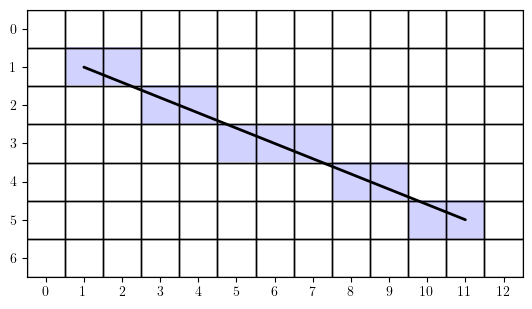

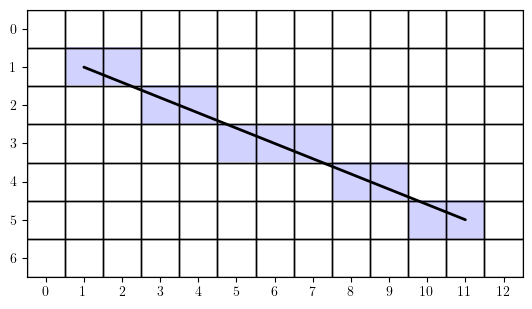

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from myst_nb import glue
plt.rcParams['text.usetex'] = True

def drawline(img, x0, y0, x1, y1, colour):
    x, y, dx, dy = x0, y0, abs(x1 - x0), abs(y1 - y0)
    D = dx - dy
    xstep, ystep = 1, 1
    if x0 > x1:
        xstep = -1
    if y0 > y1:
        ystep = -1
    while True:
        img[y, x, :] = colour
        if x == x1 and y == y1:
            return img
        E = 2 * D
        if E >= -dy:
            x += xstep
            D -= dy
        if E <= dx:
            y += ystep
            D += dx
        
def rasteriseline(Nx, Ny, x0, y0, x1, y1):
    img = 255 * np.ones((Ny, Nx, 3)).astype(int)
    img = drawline(img, x0, y0, x1, y1, blue)
    fig, ax = plt.subplots()
    imgplot = plt.imshow(img)
    plt.plot([x0, x1], [y0, y1], "k", lw=2, solid_capstyle="round")
    for i in range(Nx):
        for j in range(Ny):
            ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
    
    plt.xticks(range(Nx))
    return fig

        
Nx, Ny = 13, 7
x0, y0 = 1, 1
x1, y1 = 11, 5
blue = [210, 210, 255]
green = [230, 255, 230]
white = [255, 255, 255]
fig = rasteriseline(Nx, Ny, x0, y0, x1, y1)

glue("line-raster-plot", fig, display=False)

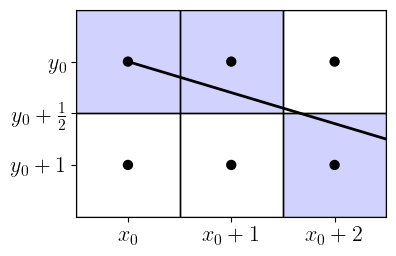

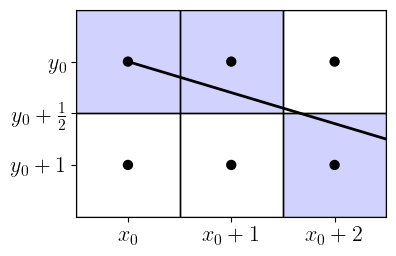

In [2]:
Nx, Ny = 3, 2
img = 255 * np.ones((Ny, Nx, 3)).astype(int)
img[0,0:2,:] = blue
img[1,2,:] = blue

fig, ax = plt.subplots(figsize=(4, 4))

imgplot = plt.imshow(img)
plt.plot([0, 2.5], [0, 0.75], "k", lw=2, solid_capstyle="round")
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
        ax.add_patch(plt.Circle((i, j), 0.05, fc="k"))
   
plt.yticks([0, 0.5, 1], [f"$y_0$", rf"$y_0+\frac{{1}}{{2}}$", f"$y_0 + 1$"], fontsize=16)
plt.xticks([0, 1, 2],[f"$x_0$", f"$x_0+1$", f"$x_0+2$"], fontsize=16)

glue("bresenham-plot-1", fig, display=False)

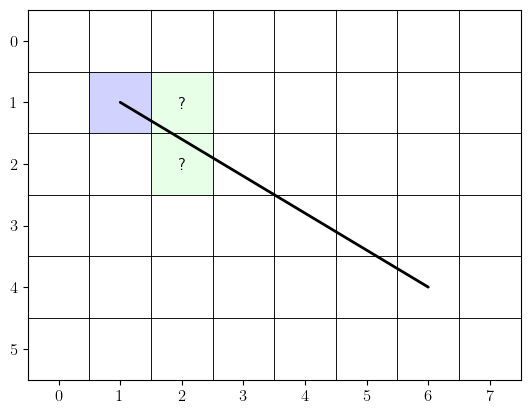

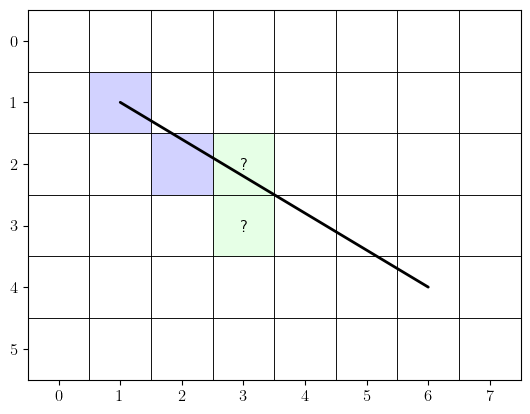

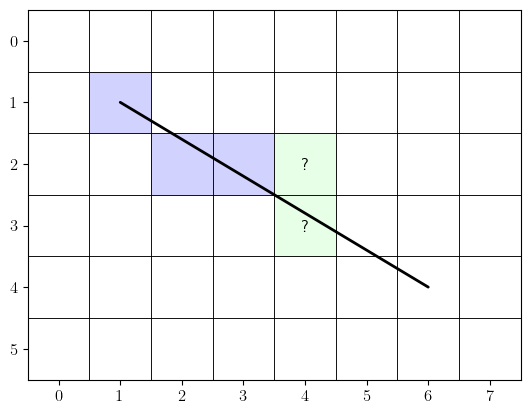

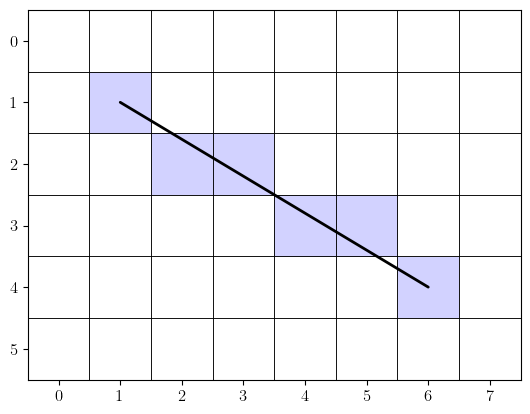

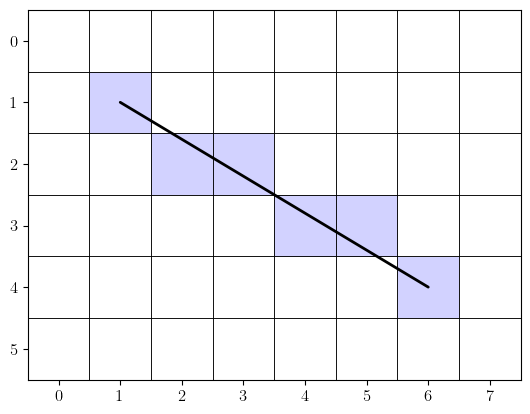

In [3]:
Nx, Ny = 8, 6
img = 255 * np.ones((Ny, Nx, 3)).astype(int)

fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=12)

img[1,1,:] = blue
img[1:3,2,:] = green
mark1 = plt.text(2, 1.1, s="?", ha="center", fontsize=12)
mark2 = plt.text(2, 2.1, s="?", ha="center", fontsize=12)
imgplot = plt.imshow(img)
plt.plot([1, 6], [1, 4], "k", lw=2, solid_capstyle="round")
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", lw=0.5, fill=False))

glue("bresenham-example1-plot-1", fig, display=False)    

img[2,2,:] = blue
img[1,2,:] = [255, 255, 255]
img[2:4,3,:] = green
mark1.set_position((3, 2.1))
mark2.set_position((3, 3.1))
imgplot = plt.imshow(img)

glue("bresenham-example1-plot-2", fig, display=False) 

img[3,3,:] = white
img[2,3,:] = blue
img[2:4,4,:] = green
mark1.set_position((4, 3.1))
mark2.set_position((4, 2.1))
imgplot = plt.imshow(img)

glue("bresenham-example1-plot-3", fig, display=False) 

img[2,4,:] = white
img[3,4:6,:] = blue
img[4,6,:] = blue
mark1.set_visible(False)
mark2.set_visible(False)
imgplot = plt.imshow(img)

glue("bresenham-example1-plot-4", fig, display=False) 

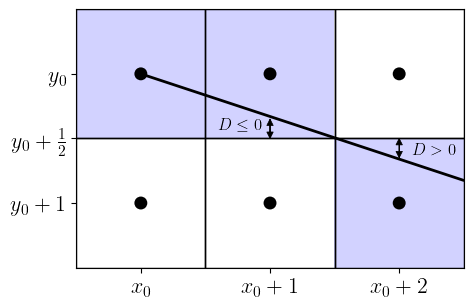

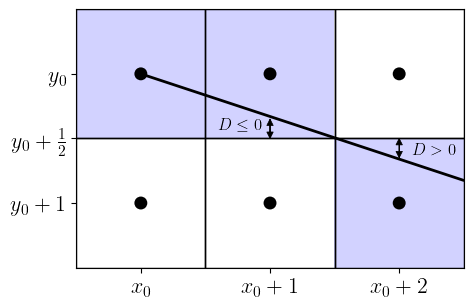

In [4]:
Nx, Ny = 3, 2
img = 255 * np.ones((Ny, Nx, 3)).astype(int)
img[0,0:2,:] = blue
img[1,2,:] = blue

fig, ax = plt.subplots(figsize=(5,5))

imgplot = plt.imshow(img)
plt.plot([0, 2.5], [0, 0.825], "k", lw=2, solid_capstyle="round")
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
        ax.add_patch(plt.Circle((i, j), 0.05, fc="k"))
   
plt.yticks([0, 0.5, 1], [f"$y_0$", rf"$y_0+\frac{{1}}{{2}}$", f"$y_0 + 1$"], fontsize=16)
plt.xticks([0, 1, 2],[f"$x_0$", f"$x_0+1$", f"$x_0+2$"], fontsize=16)
plt.arrow(1, 0.5, 0, -0.15, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.arrow(1, 0.35, 0, 0.15, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.text(0.6, 0.425, rf"$D \leq 0$", fontsize=12)
plt.arrow(2, 0.5, 0, 0.15, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.arrow(2, 0.65, 0, -0.15, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.text(2.1, 0.625, rf"$D > 0$", fontsize=12)

glue("bresenham-plot-2", fig, display=False)

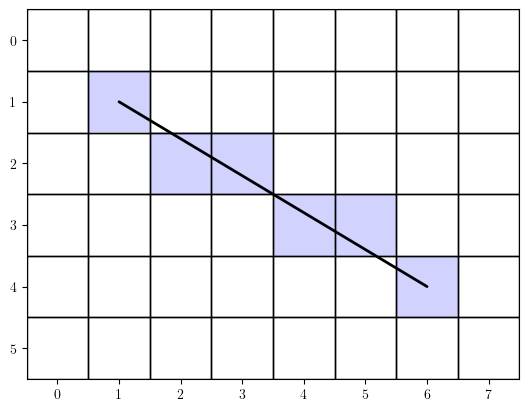

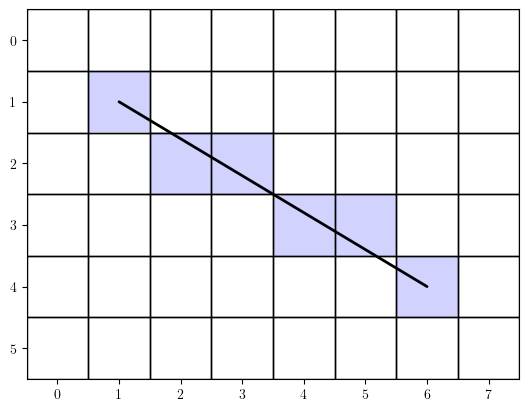

In [5]:
Nx, Ny = 8, 6
x0, y0 = 1, 1
x1, y1 = 6, 4
fig = rasteriseline(Nx, Ny, x0, y0, x1, y1)
   
glue("bresenham-example-plot-1", fig, display=False)

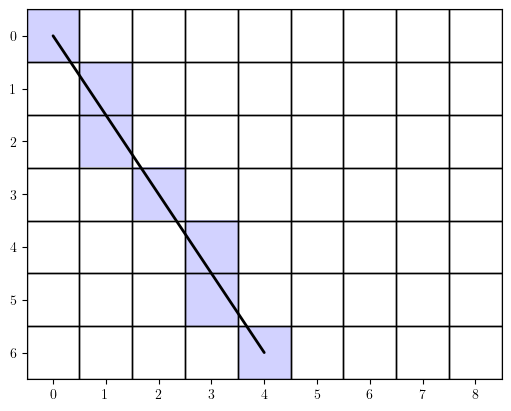

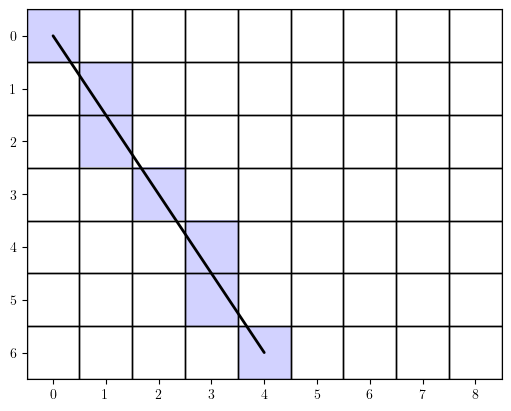

In [6]:
Nx, Ny = 9, 7
x0, y0 = 0, 0
x1, y1 = 4, 6
fig = rasteriseline(Nx, Ny, x0, y0, x1, y1)
   
glue("bresenham-example-plot-2", fig, display=False)

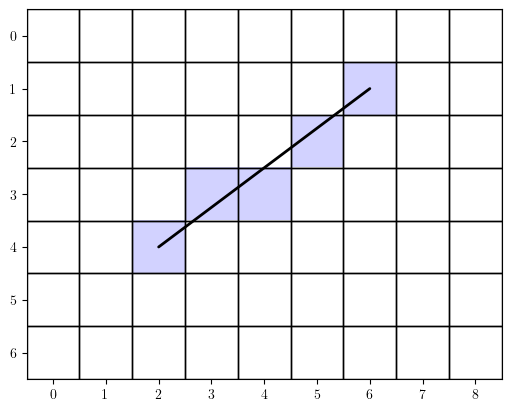

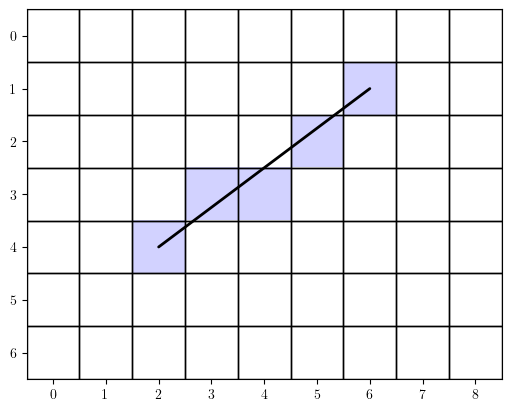

In [7]:
x0, y0 = 6, 1
x1, y1 = 2, 4
fig = rasteriseline(Nx, Ny, x0, y0, x1, y1)
   
glue("bresenham-example-plot-3", fig, display=False)